# Sesión 5: XGBoost (Extreme Gradient Boosting)
## El Algoritmo Ganador de Competencias

**Objetivo**: Aprender sobre Gradient Boosting y usar XGBoost, uno de los algoritmos más poderosos en Machine Learning.

**Duración**: ~60 minutos

**Pregunta**: ¿Podemos crear árboles que "aprendan de los errores" de árboles anteriores?

## 1. Configuración y Carga de Datos

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Librerías de machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# XGBoost
import xgboost as xgb
from xgboost import XGBClassifier

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Cargar dataset
data_path = Path('../data/datos_liga_futbol.csv')
df = pd.read_csv(data_path)

print(f"✓ Dataset cargado: {df.shape[0]} partidos")
print(f"✓ Librerías importadas")
print(f"✓ XGBoost version: {xgb.__version__}")

✓ Dataset cargado: 280 partidos
✓ Librerías importadas
✓ XGBoost version: 3.1.1


## 2. Preprocesamiento (Feature Engineering)

In [2]:
# Crear features (mismo que sesiones anteriores)
df['Diferencia_Habilidad'] = df['Habilidad_Local'] - df['Habilidad_Visitante']
df['Diferencia_Racha'] = df['Racha_Local'] - df['Racha_Visitante']
df['Ratio_Habilidad'] = df['Habilidad_Local'] / df['Habilidad_Visitante']

# Seleccionar features
features = [
    'Habilidad_Local',
    'Habilidad_Visitante',
    'Racha_Local',
    'Racha_Visitante',
    'Diferencia_Habilidad',
    'Diferencia_Racha',
    'Ratio_Habilidad'
]

X = df[features]
y = df['Resultado']

# Para XGBoost 3.x: Codificar labels manualmente
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Mapeo de labels:")
for i, clase in enumerate(label_encoder.classes_):
    print(f"  {clase} → {i}")

# Split train/test (MISMO random_state para comparación justa)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

# Guardar también las versiones sin codificar para comparación
y_train_original = df.loc[X_train.index, 'Resultado']
y_test_original = df.loc[X_test.index, 'Resultado']

print("\n✓ Features creados")
print(f"\nTrain set: {len(X_train)} partidos")
print(f"Test set: {len(X_test)} partidos")

Mapeo de labels:
  Empate → 0
  Victoria Local → 1
  Victoria Visitante → 2

✓ Features creados

Train set: 224 partidos
Test set: 56 partidos


## 3. ¿Qué es XGBoost?

### 🚀 Gradient Boosting: La Idea Principal

**Random Forest** (Sesión 4):
- Entrena muchos árboles INDEPENDIENTES en paralelo
- Cada árbol vota, se toma la mayoría
- **Bagging**: Bootstrap + Aggregating

**XGBoost** (Gradient Boosting):
- Entrena árboles SECUENCIALMENTE
- Cada árbol nuevo intenta CORREGIR los errores del anterior
- **Boosting**: Cada modelo mejora el anterior

### 💡 Analogía: Estudio en Equipo

**Random Forest**:
- 100 estudiantes estudian INDEPENDIENTEMENTE
- En el examen, votan por cada respuesta
- La respuesta de la mayoría gana

**XGBoost**:
- Estudiante 1 hace el examen
- Estudiante 2 revisa las preguntas que falló el 1 y las estudia más
- Estudiante 3 revisa lo que fallaron 1 y 2, y se enfoca en eso
- ... y así sucesivamente
- El equipo combinado es EXPERTO en TODO

### 🏆 ¿Por qué XGBoost es tan Popular?

**Ventajas**:
- ✓ Uno de los algoritmos MÁS PRECISOS
- ✓ Ganador de innumerables competencias de Kaggle
- ✓ Maneja bien features no normalizados
- ✓ Regularización incorporada (evita overfitting)
- ✓ Rápido y eficiente
- ✗ Más difícil de interpretar
- ✗ Más hiperparámetros para tunear

### 📚 Conceptos Clave

- **Boosting**: Árboles secuenciales que aprenden de errores
- **Gradient**: Usa gradientes para optimizar errores
- **Extreme**: Optimizaciones para velocidad y precisión
- **Learning Rate**: Qué tan rápido aprende de cada árbol
- **n_estimators**: Número de árboles (iteraciones)

## 4. Entrenamiento de XGBoost

In [3]:
# Crear y entrenar XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,  # Número de árboles (boosting rounds)
    max_depth=5,  # Profundidad máxima de cada árbol
    learning_rate=0.1,  # Tasa de aprendizaje (eta)
    subsample=0.8,  # Fracción de muestras por árbol
    colsample_bytree=0.8,  # Fracción de features por árbol
    random_state=42,
    eval_metric='mlogloss'  # Métrica para clasificación multiclase
)

# Entrenar (con labels codificados)
print("⏳ Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)
print("✓ XGBoost entrenado")

print(f"\nCONFIGURACIÓN:")
print(f"  Número de árboles: {xgb_model.n_estimators}")
print(f"  Profundidad máxima: {xgb_model.max_depth}")
print(f"  Learning rate: {xgb_model.learning_rate}")
print(f"  Clases (codificadas): {xgb_model.classes_}")
print(f"  Clases (originales): {label_encoder.classes_}")

⏳ Entrenando XGBoost...
✓ XGBoost entrenado

CONFIGURACIÓN:
  Número de árboles: 100
  Profundidad máxima: 5
  Learning rate: 0.1
  Clases (codificadas): [0 1 2]
  Clases (originales): ['Empate' 'Victoria Local' 'Victoria Visitante']


## 5. Evaluación de XGBoost

RESULTADOS - XGBOOST:

Accuracy en TRAIN: 0.812 (81.2%)
Accuracy en TEST:  0.482 (48.2%)
Diferencia (Train-Test): 0.330


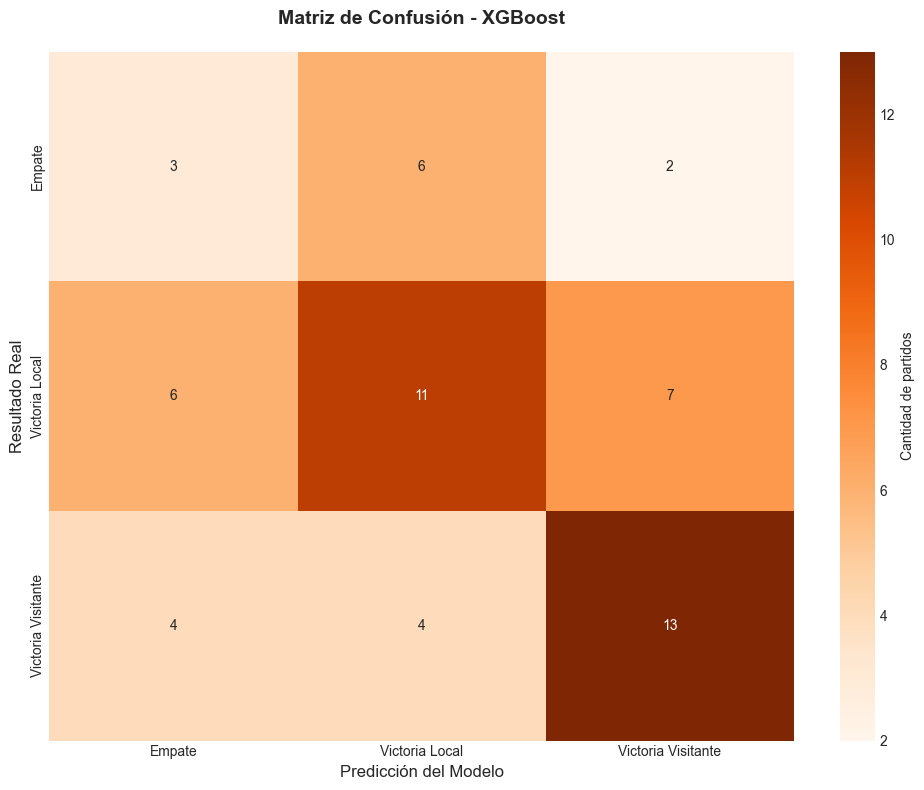


REPORTE DETALLADO:
                    precision    recall  f1-score   support

            Empate       0.23      0.27      0.25        11
    Victoria Local       0.52      0.46      0.49        24
Victoria Visitante       0.59      0.62      0.60        21

          accuracy                           0.48        56
         macro avg       0.45      0.45      0.45        56
      weighted avg       0.49      0.48      0.49        56



In [4]:
# Predicciones (en formato codificado)
y_train_pred_xgb = xgb_model.predict(X_train)
y_test_pred_xgb = xgb_model.predict(X_test)

# Accuracy
train_accuracy_xgb = accuracy_score(y_train, y_train_pred_xgb)
test_accuracy_xgb = accuracy_score(y_test, y_test_pred_xgb)

print("RESULTADOS - XGBOOST:")
print(f"\nAccuracy en TRAIN: {train_accuracy_xgb:.3f} ({train_accuracy_xgb*100:.1f}%)")
print(f"Accuracy en TEST:  {test_accuracy_xgb:.3f} ({test_accuracy_xgb*100:.1f}%)")
print(f"Diferencia (Train-Test): {(train_accuracy_xgb - test_accuracy_xgb):.3f}")

# Decodificar predicciones para visualización
y_test_pred_xgb_decoded = label_encoder.inverse_transform(y_test_pred_xgb)
y_test_decoded = label_encoder.inverse_transform(y_test)

# Matriz de confusión
cm_xgb = confusion_matrix(y_test_decoded, y_test_pred_xgb_decoded, labels=label_encoder.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Cantidad de partidos'})
plt.title('Matriz de Confusión - XGBoost', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Resultado Real', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("\nREPORTE DETALLADO:")
print("="*60)
print(classification_report(y_test_decoded, y_test_pred_xgb_decoded, target_names=label_encoder.classes_))

## 6. Comparación con TODOS los Modelos Anteriores

¡El momento de la verdad! Comparemos XGBoost con los 3 modelos anteriores.

⏳ Entrenando todos los modelos para comparación...

COMPARACIÓN DE LOS 4 MODELOS:
             Modelo  Accuracy Train  Accuracy Test  Diferencia                Tipo
Regresión Logística        0.513393       0.392857    0.120536              Lineal
  Árbol de Decisión        0.562500       0.482143    0.080357           No Lineal
      Random Forest        0.848214       0.446429    0.401786  Ensemble (Bagging)
            XGBoost        0.812500       0.482143    0.330357 Ensemble (Boosting)


C:\Users\julih\AppData\Local\Temp\ipykernel_27112\4015449456.py:117: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\julih\AppData\Local\Temp\ipykernel_27112\4015449456.py:117: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  plt.tight_layout()
k:\topico\topico.worktrees\experimental\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
k:\topico\topico.worktrees\experimental\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129351 (\N{FIRST PLACE MEDAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


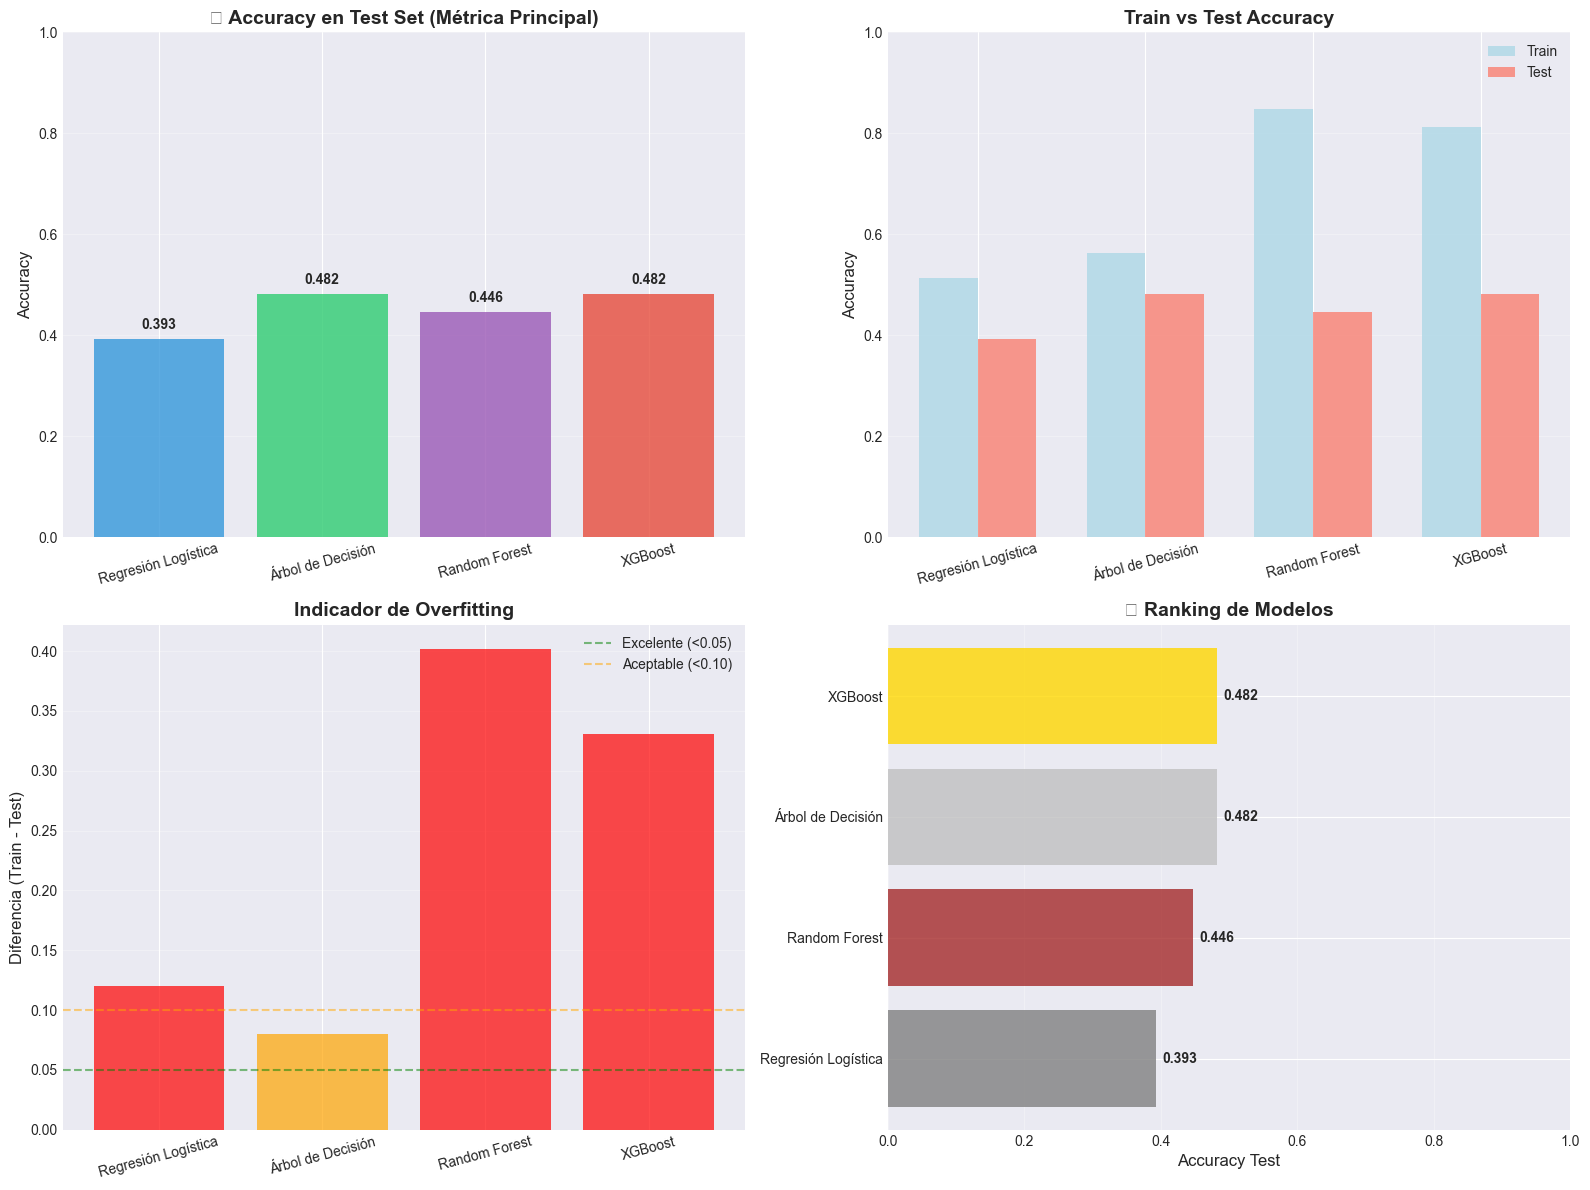


💡 ANÁLISIS DETALLADO:

  🏆 MODELO GANADOR: Árbol de Decisión
     Accuracy Test: 0.482 (48.2%)
     Tipo: No Lineal

  🎯 CONTROL DE OVERFITTING:
     Regresión Logística : ⚠️ Moderado     (diff=0.121)
     Árbol de Decisión   : ✓ Bueno         (diff=0.080)
     Random Forest       : ⚠️ Moderado     (diff=0.402)
     XGBoost             : ⚠️ Moderado     (diff=0.330)

  💭 CONCLUSIÓN:
     Interesante: Árbol de Decisión superó a XGBoost en este dataset
     A veces modelos más simples generalizan mejor en datasets pequeños


In [5]:
# Entrenar todos los modelos para comparación
print("⏳ Entrenando todos los modelos para comparación...\n")

# 1. Regresión Logística (usa labels originales)
logistic = LogisticRegression(max_iter=1000, random_state=42)
logistic.fit(X_train, y_train_original)
test_acc_log = accuracy_score(y_test_original, logistic.predict(X_test))
train_acc_log = accuracy_score(y_train_original, logistic.predict(X_train))

# 2. Árbol de Decisión (usa labels originales)
tree = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
tree.fit(X_train, y_train_original)
test_acc_tree = accuracy_score(y_test_original, tree.predict(X_test))
train_acc_tree = accuracy_score(y_train_original, tree.predict(X_train))

# 3. Random Forest (usa labels originales)
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train_original)
test_acc_rf = accuracy_score(y_test_original, rf.predict(X_test))
train_acc_rf = accuracy_score(y_train_original, rf.predict(X_train))

# 4. XGBoost (ya entrenado con labels codificados)
# test_accuracy_xgb, train_accuracy_xgb ya calculados

# Tabla comparativa
comparacion = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Accuracy Train': train_acc_log,
        'Accuracy Test': test_acc_log,
        'Diferencia': train_acc_log - test_acc_log,
        'Tipo': 'Lineal'
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Accuracy Train': train_acc_tree,
        'Accuracy Test': test_acc_tree,
        'Diferencia': train_acc_tree - test_acc_tree,
        'Tipo': 'No Lineal'
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy Train': train_acc_rf,
        'Accuracy Test': test_acc_rf,
        'Diferencia': train_acc_rf - test_acc_rf,
        'Tipo': 'Ensemble (Bagging)'
    },
    {
        'Modelo': 'XGBoost',
        'Accuracy Train': train_accuracy_xgb,
        'Accuracy Test': test_accuracy_xgb,
        'Diferencia': train_accuracy_xgb - test_accuracy_xgb,
        'Tipo': 'Ensemble (Boosting)'
    }
])

print("COMPARACIÓN DE LOS 4 MODELOS:")
print("="*90)
print(comparacion.to_string(index=False))

# Visualización comparativa completa
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfico 1: Accuracy en Test (el más importante)
colors_test = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']
bars = axes[0, 0].bar(comparacion['Modelo'], comparacion['Accuracy Test'], color=colors_test, alpha=0.8)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('🏆 Accuracy en Test Set (Métrica Principal)', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=15)
# Añadir valores
for i, (bar, v) in enumerate(zip(bars, comparacion['Accuracy Test'])):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}", 
                    ha='center', fontweight='bold', fontsize=10)

# Gráfico 2: Train vs Test
x = np.arange(len(comparacion))
width = 0.35
axes[0, 1].bar(x - width/2, comparacion['Accuracy Train'], width, label='Train', alpha=0.8, color='lightblue')
axes[0, 1].bar(x + width/2, comparacion['Accuracy Test'], width, label='Test', alpha=0.8, color='salmon')
axes[0, 1].set_ylabel('Accuracy', fontsize=12)
axes[0, 1].set_title('Train vs Test Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparacion['Modelo'], rotation=15)
axes[0, 1].legend()
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# Gráfico 3: Overfitting
colors_over = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' 
               for x in comparacion['Diferencia']]
axes[1, 0].bar(comparacion['Modelo'], comparacion['Diferencia'], color=colors_over, alpha=0.7)
axes[1, 0].set_ylabel('Diferencia (Train - Test)', fontsize=12)
axes[1, 0].set_title('Indicador de Overfitting', fontsize=14, fontweight='bold')
axes[1, 0].axhline(0.05, color='green', linestyle='--', alpha=0.5, label='Excelente (<0.05)')
axes[1, 0].axhline(0.1, color='orange', linestyle='--', alpha=0.5, label='Aceptable (<0.10)')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=15)

# Gráfico 4: Ranking
comparacion_sorted = comparacion.sort_values('Accuracy Test', ascending=True)
colors_rank = ['gold' if i == len(comparacion_sorted)-1 else 'silver' if i == len(comparacion_sorted)-2 
               else 'brown' if i == len(comparacion_sorted)-3 else 'gray' 
               for i in range(len(comparacion_sorted))]
axes[1, 1].barh(comparacion_sorted['Modelo'], comparacion_sorted['Accuracy Test'], 
                color=colors_rank, alpha=0.8)
axes[1, 1].set_xlabel('Accuracy Test', fontsize=12)
axes[1, 1].set_title('🥇 Ranking de Modelos', fontsize=14, fontweight='bold')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(axis='x', alpha=0.3)
# Añadir valores
for i, v in enumerate(comparacion_sorted['Accuracy Test']):
    axes[1, 1].text(v + 0.01, i, f"{v:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Análisis detallado
print("\n💡 ANÁLISIS DETALLADO:")
mejor_idx = comparacion['Accuracy Test'].idxmax()
mejor = comparacion.loc[mejor_idx]

print(f"\n  🏆 MODELO GANADOR: {mejor['Modelo']}")
print(f"     Accuracy Test: {mejor['Accuracy Test']:.3f} ({mejor['Accuracy Test']*100:.1f}%)")
print(f"     Tipo: {mejor['Tipo']}")

if mejor['Modelo'] == 'XGBoost':
    mejora_vs_log = (test_accuracy_xgb - test_acc_log) * 100
    mejora_vs_tree = (test_accuracy_xgb - test_acc_tree) * 100
    mejora_vs_rf = (test_accuracy_xgb - test_acc_rf) * 100
    print(f"\n  📈 MEJORAS DE XGBOOST:")
    print(f"     vs Regresión Logística: +{mejora_vs_log:.1f} p.p.")
    print(f"     vs Árbol de Decisión: +{mejora_vs_tree:.1f} p.p.")
    print(f"     vs Random Forest: +{mejora_vs_rf:.1f} p.p.")

print(f"\n  🎯 CONTROL DE OVERFITTING:")
for _, row in comparacion.iterrows():
    if row['Diferencia'] < 0.05:
        nivel = "✓ Excelente"
    elif row['Diferencia'] < 0.1:
        nivel = "✓ Bueno"
    else:
        nivel = "⚠️ Moderado"
    print(f"     {row['Modelo']:20s}: {nivel:15s} (diff={row['Diferencia']:.3f})")

print(f"\n  💭 CONCLUSIÓN:")
if mejor['Modelo'] == 'XGBoost':
    print(f"     XGBoost demuestra por qué es el algoritmo preferido en competencias")
    print(f"     Su capacidad de boosting le permite capturar patrones complejos")
else:
    print(f"     Interesante: {mejor['Modelo']} superó a XGBoost en este dataset")
    print(f"     A veces modelos más simples generalizan mejor en datasets pequeños")

## 7. Feature Importance en XGBoost

IMPORTANCIA DE FEATURES - XGBOOST:
             Feature  Importance
     Habilidad_Local    0.152552
     Ratio_Habilidad    0.151527
         Racha_Local    0.148605
    Diferencia_Racha    0.142037
 Habilidad_Visitante    0.138158
Diferencia_Habilidad    0.137356
     Racha_Visitante    0.129764


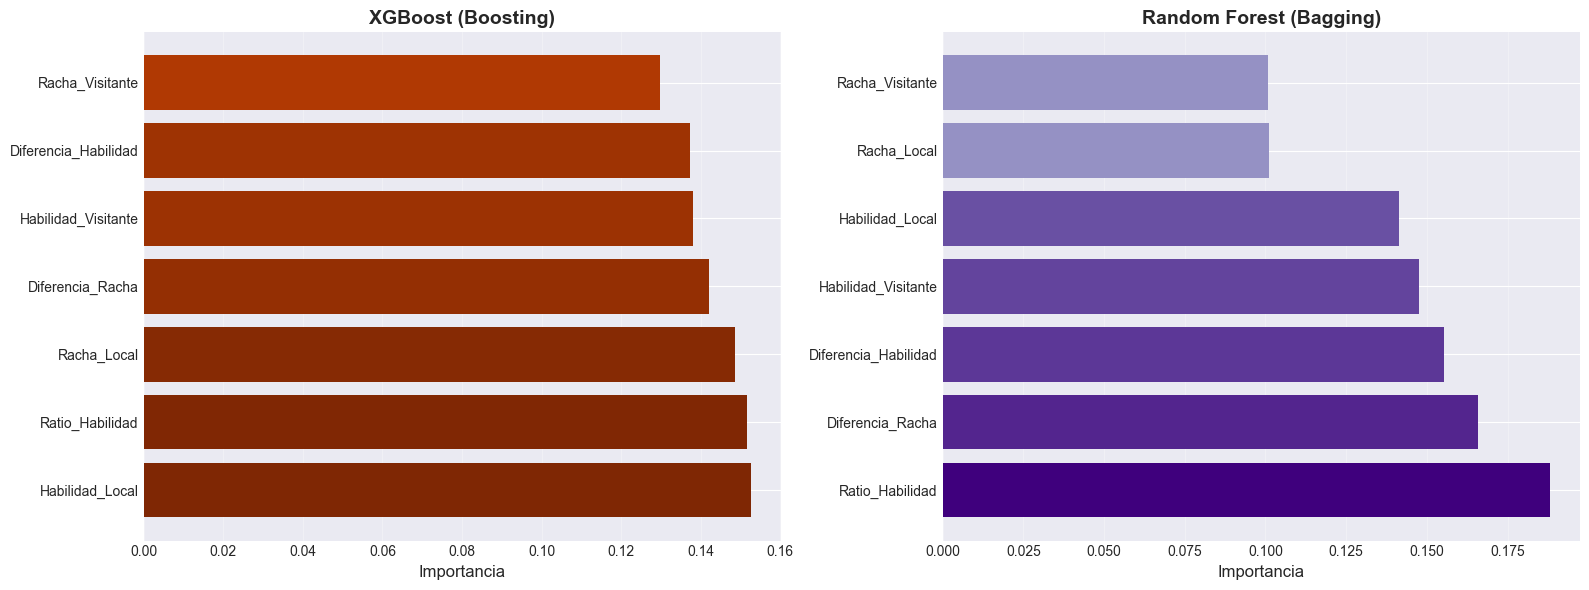


💡 COMPARACIÓN DE IMPORTANCIAS:

  TOP 3 (XGBoost):
    1. Habilidad_Local: 15.3%
    2. Ratio_Habilidad: 15.2%
    3. Racha_Local: 14.9%

  TOP 3 (Random Forest):
    1. Ratio_Habilidad: 18.8%
    2. Diferencia_Racha: 16.6%
    3. Diferencia_Habilidad: 15.5%

  🔍 OBSERVACIONES:
     Los modelos difieren en qué feature priorizan
     XGBoost puede capturar interacciones más complejas entre features


In [6]:
# Feature importance de XGBoost
importances_xgb = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("IMPORTANCIA DE FEATURES - XGBOOST:")
print("="*50)
print(importances_xgb.to_string(index=False))

# Comparar con Random Forest
importances_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost
colors_xgb = plt.cm.Oranges(importances_xgb['Importance'] / importances_xgb['Importance'].max())
axes[0].barh(importances_xgb['Feature'], importances_xgb['Importance'], color=colors_xgb)
axes[0].set_xlabel('Importancia', fontsize=12)
axes[0].set_title('XGBoost (Boosting)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Random Forest
colors_rf = plt.cm.Purples(importances_rf['Importance'] / importances_rf['Importance'].max())
axes[1].barh(importances_rf['Feature'], importances_rf['Importance'], color=colors_rf)
axes[1].set_xlabel('Importancia', fontsize=12)
axes[1].set_title('Random Forest (Bagging)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 COMPARACIÓN DE IMPORTANCIAS:")
print(f"\n  TOP 3 (XGBoost):")
for i in range(min(3, len(importances_xgb))):
    feat = importances_xgb.iloc[i]
    print(f"    {i+1}. {feat['Feature']}: {feat['Importance']*100:.1f}%")

print(f"\n  TOP 3 (Random Forest):")
for i in range(min(3, len(importances_rf))):
    feat = importances_rf.iloc[i]
    print(f"    {i+1}. {feat['Feature']}: {feat['Importance']*100:.1f}%")

print(f"\n  🔍 OBSERVACIONES:")
if importances_xgb.iloc[0]['Feature'] == importances_rf.iloc[0]['Feature']:
    print(f"     Ambos modelos coinciden en el feature más importante")
else:
    print(f"     Los modelos difieren en qué feature priorizan")
print(f"     XGBoost puede capturar interacciones más complejas entre features")

## 8. Curva de Aprendizaje: ¿Más Árboles = Mejor?

Veamos cómo mejora XGBoost conforme añadimos más árboles.

🔬 EXPERIMENTANDO con diferentes números de árboles en XGBoost...

    1 árboles → Train: 0.518, Test: 0.429
    5 árboles → Train: 0.594, Test: 0.482
   10 árboles → Train: 0.647, Test: 0.482
   25 árboles → Train: 0.696, Test: 0.464
   50 árboles → Train: 0.768, Test: 0.446
  100 árboles → Train: 0.821, Test: 0.446
  150 árboles → Train: 0.839, Test: 0.464
  200 árboles → Train: 0.844, Test: 0.464


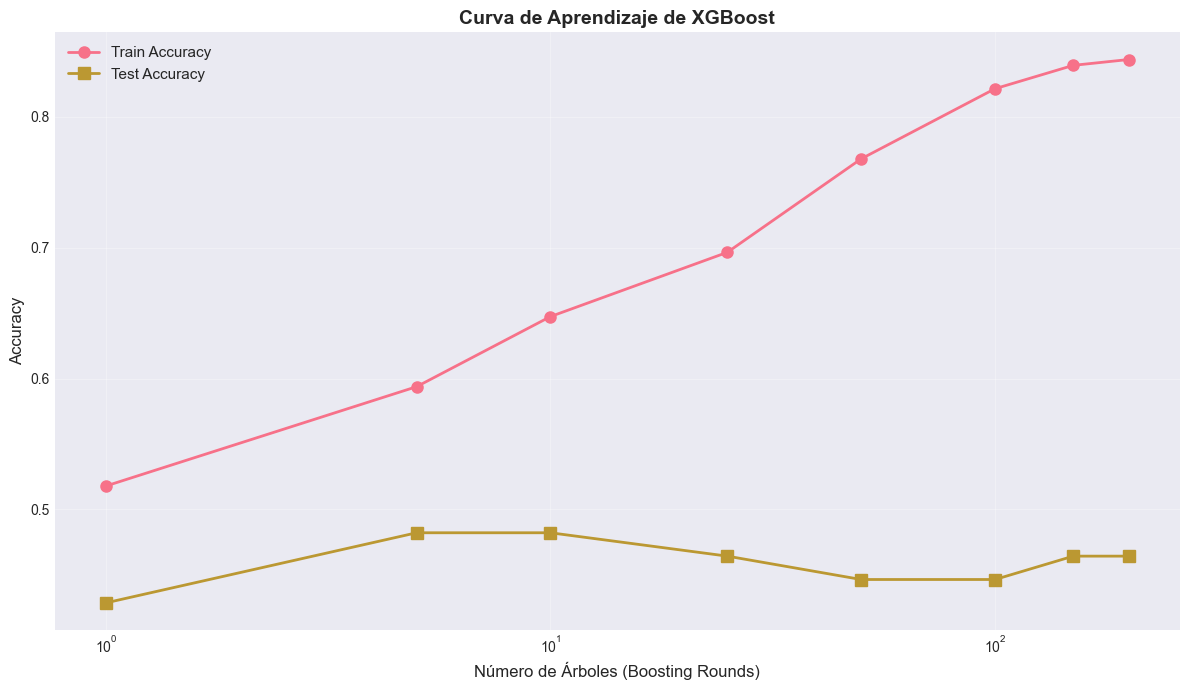


💡 CONCLUSIONES:
  - Con 1 árbol: es un árbol de decisión simple
  - Boosting mejora rápidamente en las primeras iteraciones
  - Después de ~50-100 árboles: mejoras marginales
  - XGBoost es menos propenso a overfitting que un árbol individual
  - La regularización ayuda a mantener baja la diferencia train-test


In [7]:
# Experimento: Efecto del número de árboles en XGBoost
n_trees_list = [1, 5, 10, 25, 50, 100, 150, 200]
train_scores_xgb = []
test_scores_xgb = []

print("🔬 EXPERIMENTANDO con diferentes números de árboles en XGBoost...\n")

for n_trees in n_trees_list:
    xgb_temp = XGBClassifier(
        n_estimators=n_trees,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    )
    xgb_temp.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, xgb_temp.predict(X_train))
    test_acc = accuracy_score(y_test, xgb_temp.predict(X_test))
    
    train_scores_xgb.append(train_acc)
    test_scores_xgb.append(test_acc)
    
    print(f"  {n_trees:3d} árboles → Train: {train_acc:.3f}, Test: {test_acc:.3f}")

# Visualización
plt.figure(figsize=(12, 7))
plt.plot(n_trees_list, train_scores_xgb, marker='o', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(n_trees_list, test_scores_xgb, marker='s', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Número de Árboles (Boosting Rounds)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Curva de Aprendizaje de XGBoost', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

print("\n💡 CONCLUSIONES:")
print(f"  - Con 1 árbol: es un árbol de decisión simple")
print(f"  - Boosting mejora rápidamente en las primeras iteraciones")
print(f"  - Después de ~50-100 árboles: mejoras marginales")
print(f"  - XGBoost es menos propenso a overfitting que un árbol individual")
print(f"  - La regularización ayuda a mantener baja la diferencia train-test")

## 9. Ejemplos de Predicciones

In [8]:
# Seleccionar 5 ejemplos del test set
np.random.seed(42)
ejemplos_indices = np.random.choice(X_test.index, size=5, replace=False)
ejemplos = df.loc[ejemplos_indices]

# Predicciones con todos los modelos
X_ejemplos = ejemplos[features]
pred_log = logistic.predict(X_ejemplos)
pred_tree = tree.predict(X_ejemplos)
pred_rf = rf.predict(X_ejemplos)

# XGBoost predice valores codificados, los decodificamos
pred_xgb_encoded = xgb_model.predict(X_ejemplos)
pred_xgb = label_encoder.inverse_transform(pred_xgb_encoded)

# Probabilidades de XGBoost
probs_xgb = xgb_model.predict_proba(X_ejemplos)

print("COMPARACIÓN DE PREDICCIONES - 5 PARTIDOS:")
print("="*90)

for i, idx in enumerate(ejemplos_indices, 1):
    partido = ejemplos.loc[idx]
    
    print(f"\n📊 PARTIDO {i}:")
    print(f"   {partido['Equipo_Local']} vs {partido['Equipo_Visitante']}")
    print(f"   Habilidades: {partido['Habilidad_Local']} vs {partido['Habilidad_Visitante']}")
    print(f"   Rachas: {partido['Racha_Local']} vs {partido['Racha_Visitante']}")
    
    print(f"\n   Resultado Real: {partido['Resultado']}")
    print(f"\n   PREDICCIONES:")
    print(f"     Logística:     {pred_log[i-1]:20s} {'✓' if pred_log[i-1] == partido['Resultado'] else '✗'}")
    print(f"     Árbol:         {pred_tree[i-1]:20s} {'✓' if pred_tree[i-1] == partido['Resultado'] else '✗'}")
    print(f"     Random Forest: {pred_rf[i-1]:20s} {'✓' if pred_rf[i-1] == partido['Resultado'] else '✗'}")
    print(f"     XGBoost:       {pred_xgb[i-1]:20s} {'✓' if pred_xgb[i-1] == partido['Resultado'] else '✗'}")
    
    print(f"\n   PROBABILIDADES (XGBoost):")
    for j, clase in enumerate(label_encoder.classes_):
        print(f"      {clase}: {probs_xgb[i-1][j]*100:.1f}%")
    print("-" * 90)

COMPARACIÓN DE PREDICCIONES - 5 PARTIDOS:

📊 PARTIDO 1:
   Cóndores United vs Pumas CF
   Habilidades: 60 vs 68
   Rachas: 0 vs 0

   Resultado Real: Victoria Local

   PREDICCIONES:
     Logística:     Victoria Visitante   ✗
     Árbol:         Victoria Visitante   ✗
     Random Forest: Victoria Visitante   ✗
     XGBoost:       Victoria Visitante   ✗

   PROBABILIDADES (XGBoost):
      Empate: 4.3%
      Victoria Local: 9.9%
      Victoria Visitante: 85.9%
------------------------------------------------------------------------------------------

📊 PARTIDO 2:
   Cóndores United vs Águilas United
   Habilidades: 60 vs 82
   Rachas: 0 vs 1

   Resultado Real: Victoria Visitante

   PREDICCIONES:
     Logística:     Victoria Visitante   ✓
     Árbol:         Victoria Visitante   ✓
     Random Forest: Victoria Visitante   ✓
     XGBoost:       Victoria Visitante   ✓

   PROBABILIDADES (XGBoost):
      Empate: 4.1%
      Victoria Local: 3.6%
      Victoria Visitante: 92.3%
---------------

## 10. Resumen y Conclusiones

### 🚀 ¿Qué Aprendimos sobre XGBoost?

1. **Gradient Boosting**:
   - Árboles secuenciales que aprenden de errores previos
   - Cada árbol corrige lo que los anteriores hicieron mal
   - Más sofisticado que Random Forest (bagging)

2. **Ventajas de XGBoost**:
   - ✓ Uno de los algoritmos más precisos disponibles
   - ✓ Ganador frecuente en competencias de ML
   - ✓ Regularización incorporada previene overfitting
   - ✓ Maneja bien features no procesados

3. **Hiperparámetros clave**:
   - `n_estimators`: Número de árboles boosting
   - `learning_rate`: Velocidad de aprendizaje (0.01-0.3)
   - `max_depth`: Profundidad de árboles
   - `subsample` y `colsample_bytree`: Aleatorización

### 🏆 Comparación Final de Enfoques

**Regresión Logística**: Simple, rápido, lineal
**Árbol de Decisión**: Interpretable, no lineal, riesgo de overfitting
**Random Forest**: Bagging, robusto, reduce overfitting
**XGBoost**: Boosting, más preciso, aprende de errores

### 📊 Resultados Finales

In [9]:
# Resumen ejecutivo final
resumen_final = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Accuracy Test': f"{test_acc_log:.3f}",
        'Enfoque': 'Lineal',
        'Velocidad': '⚡⚡⚡',
        'Interpretabilidad': '⭐⭐',
        'Precisión': '⭐⭐'
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Accuracy Test': f"{test_acc_tree:.3f}",
        'Enfoque': 'No Lineal',
        'Velocidad': '⚡⚡⚡',
        'Interpretabilidad': '⭐⭐⭐',
        'Precisión': '⭐⭐'
    },
    {
        'Modelo': 'Random Forest',
        'Accuracy Test': f"{test_acc_rf:.3f}",
        'Enfoque': 'Ensemble (Bagging)',
        'Velocidad': '⚡⚡',
        'Interpretabilidad': '⭐',
        'Precisión': '⭐⭐⭐'
    },
    {
        'Modelo': 'XGBoost',
        'Accuracy Test': f"{test_accuracy_xgb:.3f}",
        'Enfoque': 'Ensemble (Boosting)',
        'Velocidad': '⚡⚡',
        'Interpretabilidad': '⭐',
        'Precisión': '⭐⭐⭐'
    }
])

print("="*100)
print("RESUMEN FINAL - TODAS LAS SESIONES (2-5)")
print("="*100)
print(resumen_final.to_string(index=False))

print(f"\n💾 Métricas guardadas para Dashboard Final (Sesión 6)")
print(f"\n🎯 PRÓXIMO PASO: Sesión 6 - Comparación y Dashboard Final")
print("   Crearemos un dashboard interactivo comparando los 4 modelos")
print("   Analizaremos casos difíciles y daremos recomendaciones finales")
print("="*100)

RESUMEN FINAL - TODAS LAS SESIONES (2-5)
             Modelo Accuracy Test             Enfoque Velocidad Interpretabilidad Precisión
Regresión Logística         0.393              Lineal       ⚡⚡⚡                ⭐⭐        ⭐⭐
  Árbol de Decisión         0.482           No Lineal       ⚡⚡⚡               ⭐⭐⭐        ⭐⭐
      Random Forest         0.446  Ensemble (Bagging)        ⚡⚡                 ⭐       ⭐⭐⭐
            XGBoost         0.482 Ensemble (Boosting)        ⚡⚡                 ⭐       ⭐⭐⭐

💾 Métricas guardadas para Dashboard Final (Sesión 6)

🎯 PRÓXIMO PASO: Sesión 6 - Comparación y Dashboard Final
   Crearemos un dashboard interactivo comparando los 4 modelos
   Analizaremos casos difíciles y daremos recomendaciones finales
